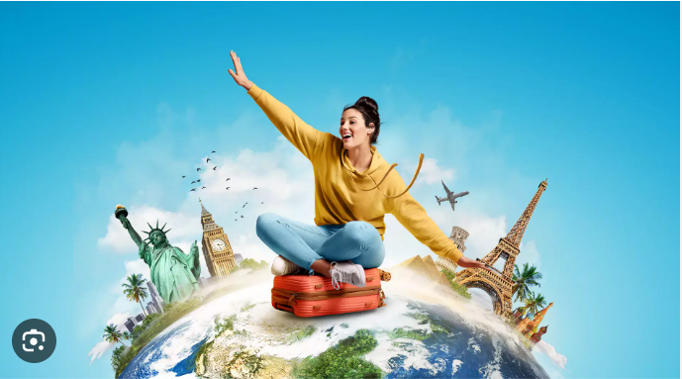

<b><h2><center>VISA STATUS</center></h2></b>

##Problem Statement


###Context
Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.


###Objective
In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

###Data Description
The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

case_id: ID of each visa application</br>

continent: Information of continent the employee</br>
education_of_employee: Information of education of the employee</br>
has_job_experience: Does the employee has any job experience? Y= Yes; N = No</br>
requires_job_training: Does the employee require any job training? Y = Yes; N = No</br>
no_of_employees: Number of employees in the employer's company</br>
yr_of_estab: Year in which the employer's company was established</br>
region_of_employment: Information of foreign worker's intended region of employment in the US.</br>
prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.</br>
unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.</br>
full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position</br>
case_status: Flag indicating if the Visa was certified or denied</br>

## Importing necessary libraries

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

## Reading the dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
visa = pd.read_csv('/content/drive/MyDrive/AIML _MBA/EasyVisa_Project/EasyVisa.csv')

In [4]:
# copying data to another varaible to avoid any changes to original data
data = visa.copy()

## Overview of the dataset

### Displaying the first and last 5 rows of the dataset

In [ ]:
data.head(5)

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,0
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,1
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,0
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,0
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,1


In [ ]:
data.tail(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


### Understand the shape of the dataset.

In [ ]:
data.shape

(25480, 12)




* There are 25,480 observations and 12 columns in the dataset

### Check the data types of the columns for the dataset.

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Observations-**
*  All columns data type is object except no_of_employee, yr_of_estab  are interger type and prevailing_wages which is float type.
* There are no missing values in the data. We can further confirm this using `isna()` method.


**Dropping columns which are not adding any information.**

In [5]:
# enrollee_id is unique for each candidate and might not add value to modeling
data.drop(["case_id"], axis=1, inplace=True)

### Checking for duplicate values

In [6]:
# let's check for duplicate values in the data
data.duplicated().sum()

0

There is no duplicate value in the data

### Checking for missing values

In [7]:
data.isna().sum()

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0


- There are no missing values in the data.

### Summary of the dataset.

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


**Observations**
* `no_of_employees:`The high standard deviation suggest a wide range in company sizes. However majority of employers(75%) have fewer than 3504 employees.
* `no_of_employees:` The min value is a negative number, we will address this in feature engineering before train test split.  
* `Yr_of_estab:` Median year (1997) indicates most companies are at least ~25+ years old. however years have a wide range from 1800 to 2016.
* `prevailing_wage:` Minimum wage ($2.14) is highly unrealistic. we will Normalize prevailing_wage to account for different wage units (Hourly, Weekly, Monthly, Yearly) in feature engineering.


## Exploratory Data Analysis

### Univariate analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

#### Observations on fixed acidity

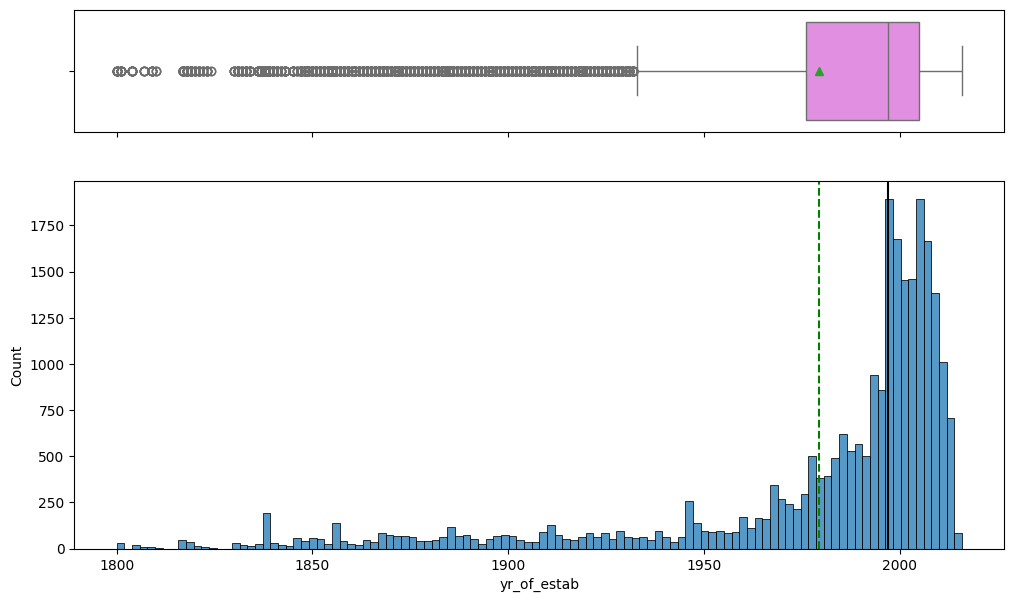

In [ ]:
histogram_boxplot(data,'yr_of_estab')

* Distribution of yr_of_estab is left-skewed.
* companies with yr_of_establish less than ~1870 are outliers.


#### Observations on no_of_employees

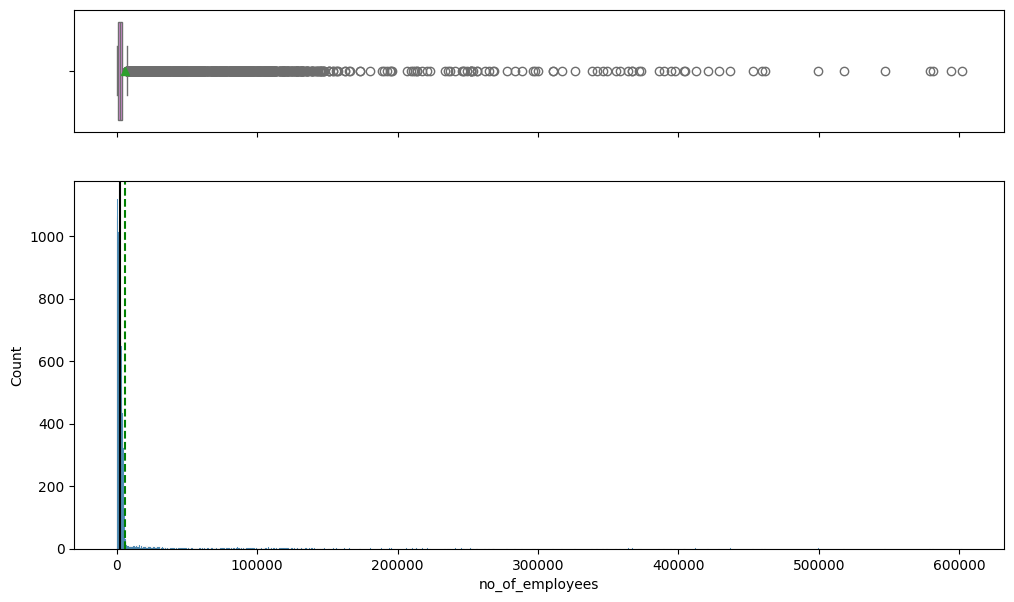

In [ ]:
histogram_boxplot(data,'no_of_employees')

* Highly Skewed Distribution: The histogram shows that most companies have a very small number of employees, while a few companies have extremely high employee counts.
* The boxplot clearly shows a large number of outliers.

#### Observations on prevailing_wage

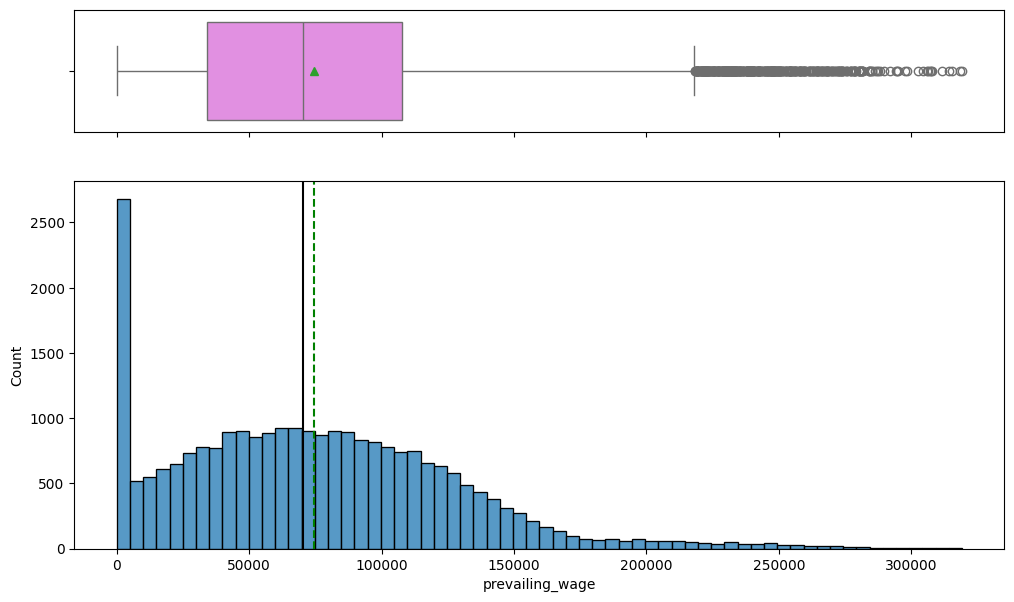

In [ ]:
histogram_boxplot(data,'prevailing_wage')

* The histogram shows that most prevailing wages fall below $100,000, but there are some extremely high values.
*  The boxplot indicates a significant number of outliers on the higher end.
* There is an unexpected spike at very low wage values close to zero.
This could indicate data errors, incorrect entries.(e.g. Hour,month,year).

In [ ]:
#Calculating top 5 values
data['prevailing_wage'].sort_values(ascending=False).head()

,prevailing_wage
21077,319210.270
14810,318446.050
12215,315497.600
16223,314156.060
20957,311734.490


In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

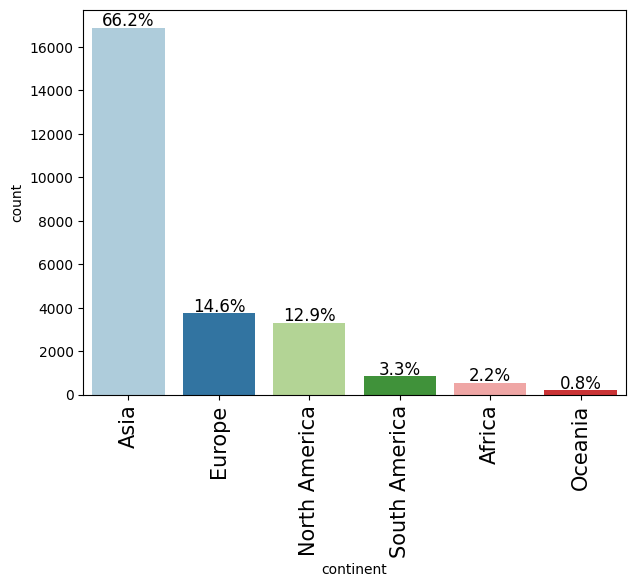

In [ ]:
labeled_barplot(data,'continent',perc=True)

* Asia is on the  top with 66% employees followed by Europe.
* From Oceania there is near about 200 employees who are applied for Visa.     

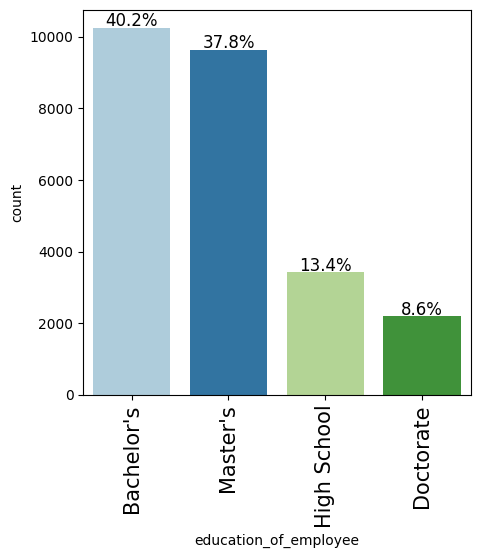

In [ ]:
labeled_barplot(data,'education_of_employee',perc=True)

* 42% of Employees holding Bachelor's are applies for visa followed Master degree holder.
* Doctorate are less in number to apply for visa.   

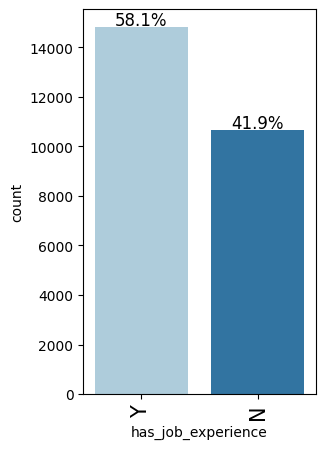

In [ ]:
labeled_barplot(data,'has_job_experience',perc=True)

* The percentage of people having Job experience more than not having any experience.



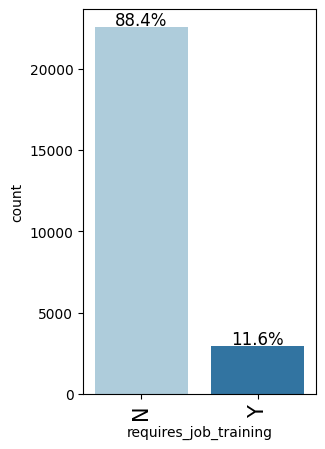

In [ ]:
labeled_barplot(data,'requires_job_training',perc=True)

* More than 88% employees are those who doesn't want any job training.
* Chances of getting Visa is more when employees are already trained.

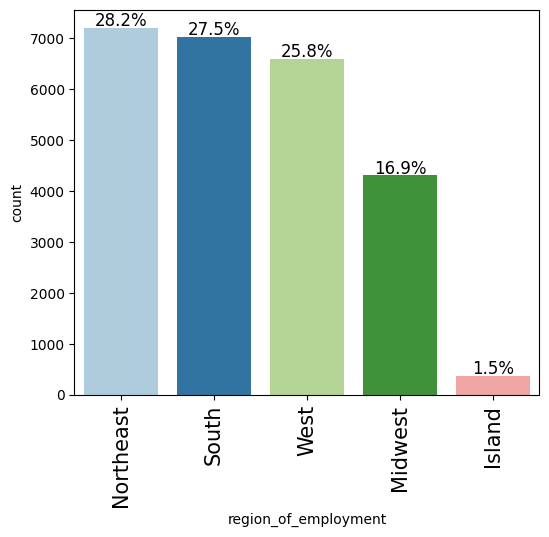

In [ ]:
labeled_barplot(data,'region_of_employment',perc=True)

* Northeast is on the top list with 28% to provide job opportunity followed by South, west region.
*Island region only having 1.5% of company located.

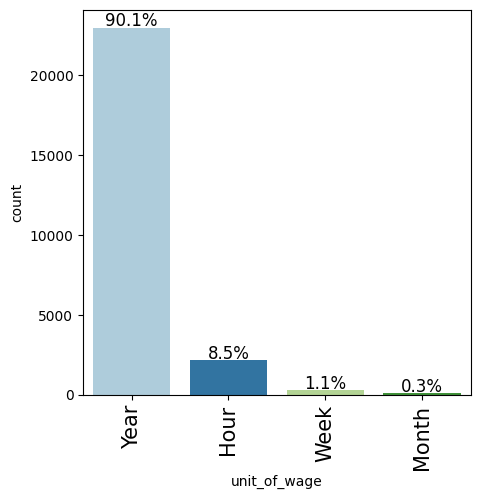

In [ ]:
labeled_barplot(data,'unit_of_wage',perc=True)

* According to this 90% of wages based on yearly.
* We need to normalize this data. we will treat this in feature engineering.

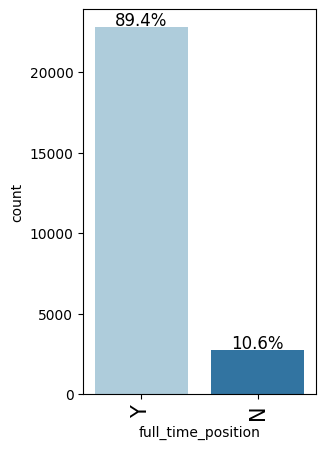

In [ ]:
labeled_barplot(data,'full_time_position',perc=True)

* Near about 90% of employees are more interested for full time employemnt.

### Bivariate Analysis

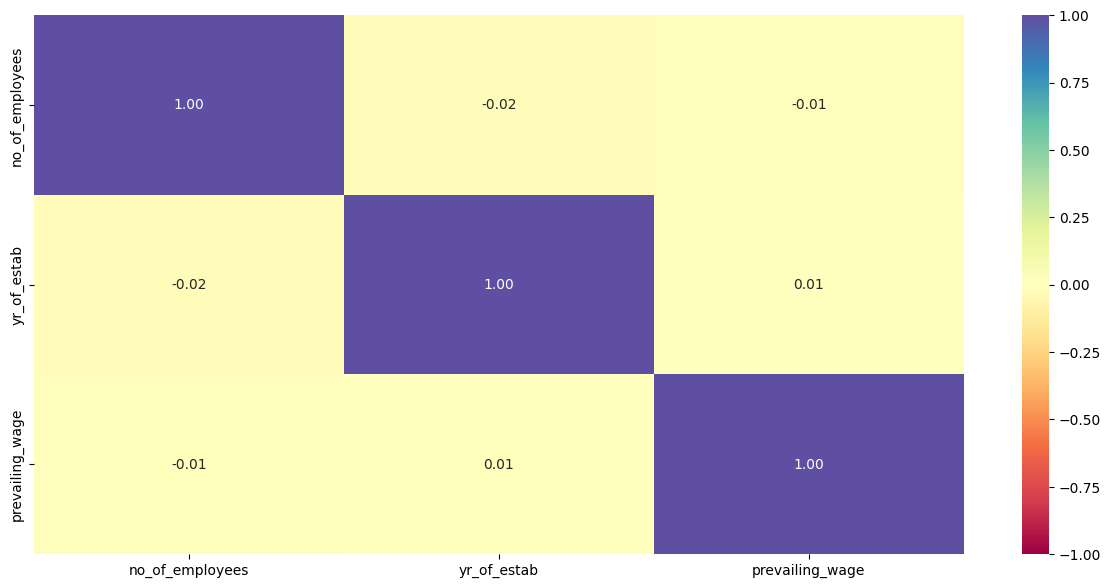

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* There is no strong correlation between any independent variable.
* No_of_employee having negative correlation with wages and year_of_establish.

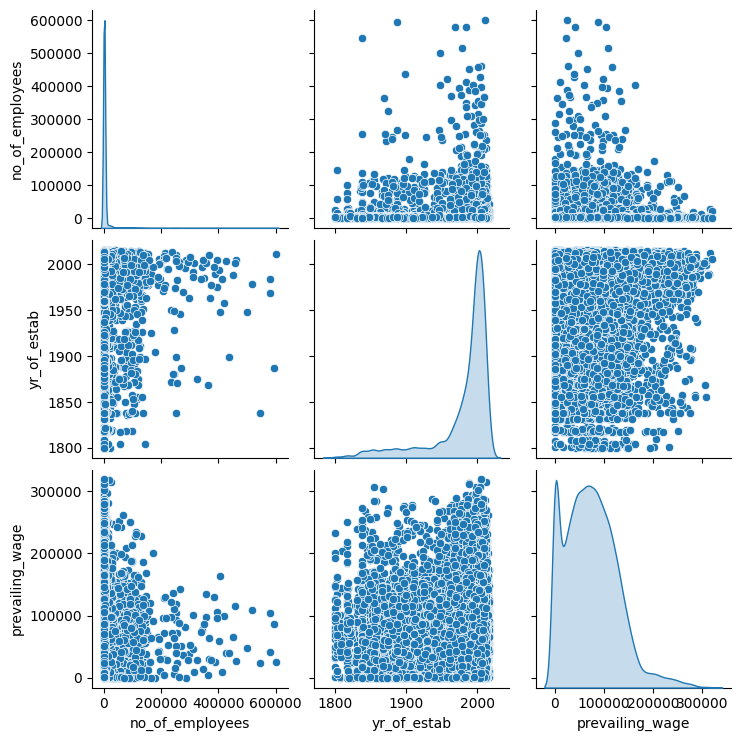

In [ ]:
sns.pairplot(data=data, diag_kind="kde")
plt.show()

* No strong linear correlation between no of_employees and prevailing wage, but companies with more employees tend to have a wider range of wages.
* according to year of establishment, Newer companies seem to offer a broad range of wages, while older companies generally have lower wages.
* Many older companies have fewer no of employees, suggesting that not all well-established companies are large.

In [ ]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

### Continent vs Visa Status

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


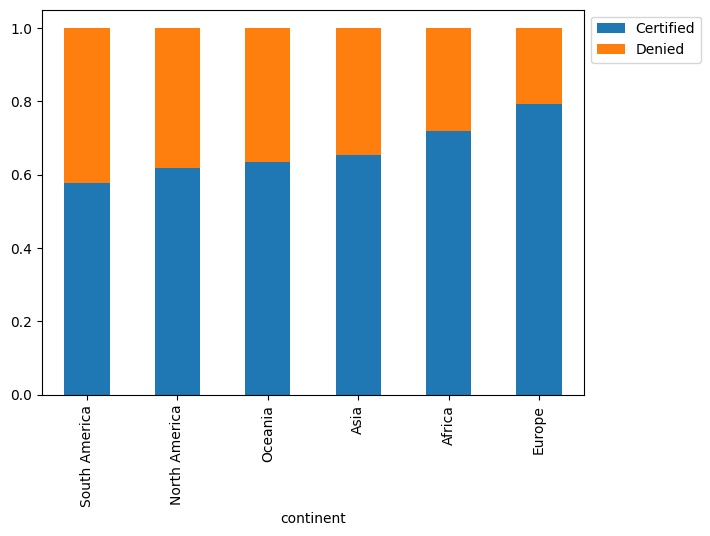

In [ ]:
stacked_barplot(data, "continent", "case_status")

* The success rate of visa is higher for european and African than other continent.
* South American & North American visa dening rate are higher

### Education vs Visa Status

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


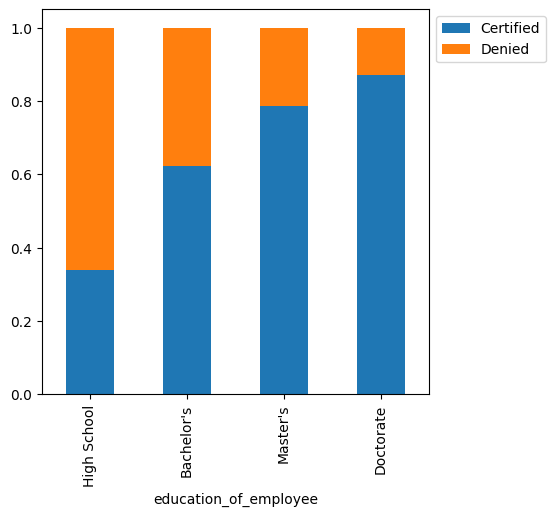

In [ ]:
stacked_barplot(data, "education_of_employee", "case_status")

* Higher the education degree lesser than chances of visa denied(Doctorate get visa esaly) .
* High School passed have more chances of visa denied.

### Region  vs Visa Status

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


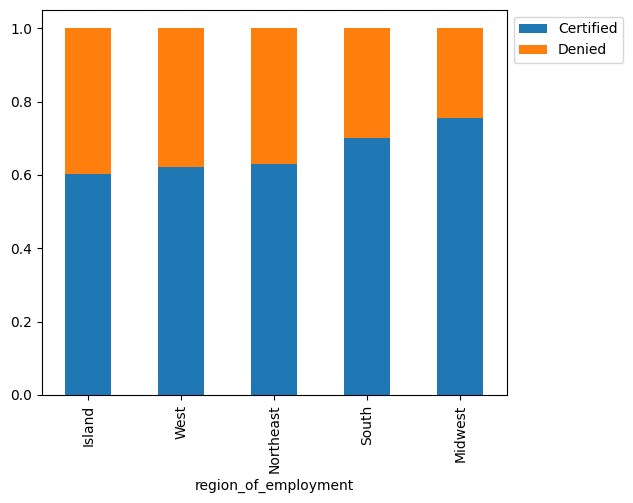

In [ ]:
stacked_barplot(data, "region_of_employment", "case_status")

* companies in Midwest and South are issued more visa than other contients.
* In Island the chances of getting visa low.

### Wages vs Visa Status

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


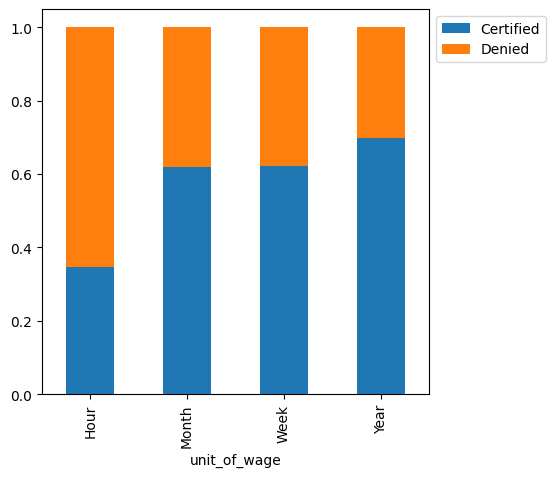

In [ ]:
stacked_barplot(data, "unit_of_wage", "case_status")

* Unit_of Wages col is not normalized yet. will do in feature engineering.

In [ ]:
### Function to plot distributions


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### No of employees vs Visa Status

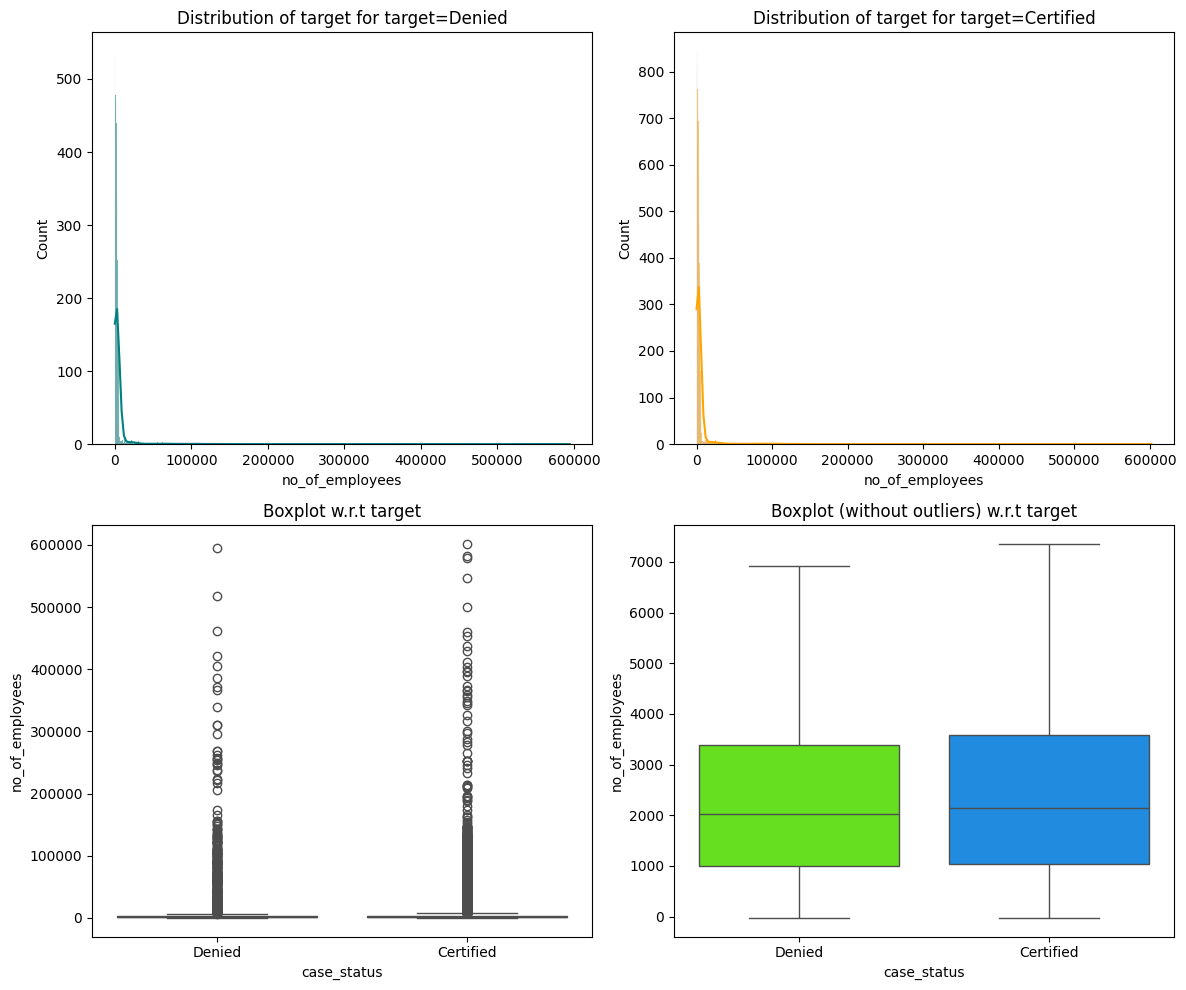

In [ ]:
distribution_plot_wrt_target(data, "no_of_employees", "case_status")

**Observation**
*	The median number of employees appears similar for both “Denied” and “Certified” cases, suggesting that the number of employees in a company does not significantly impact case approval.

### Wages vs Visa Status

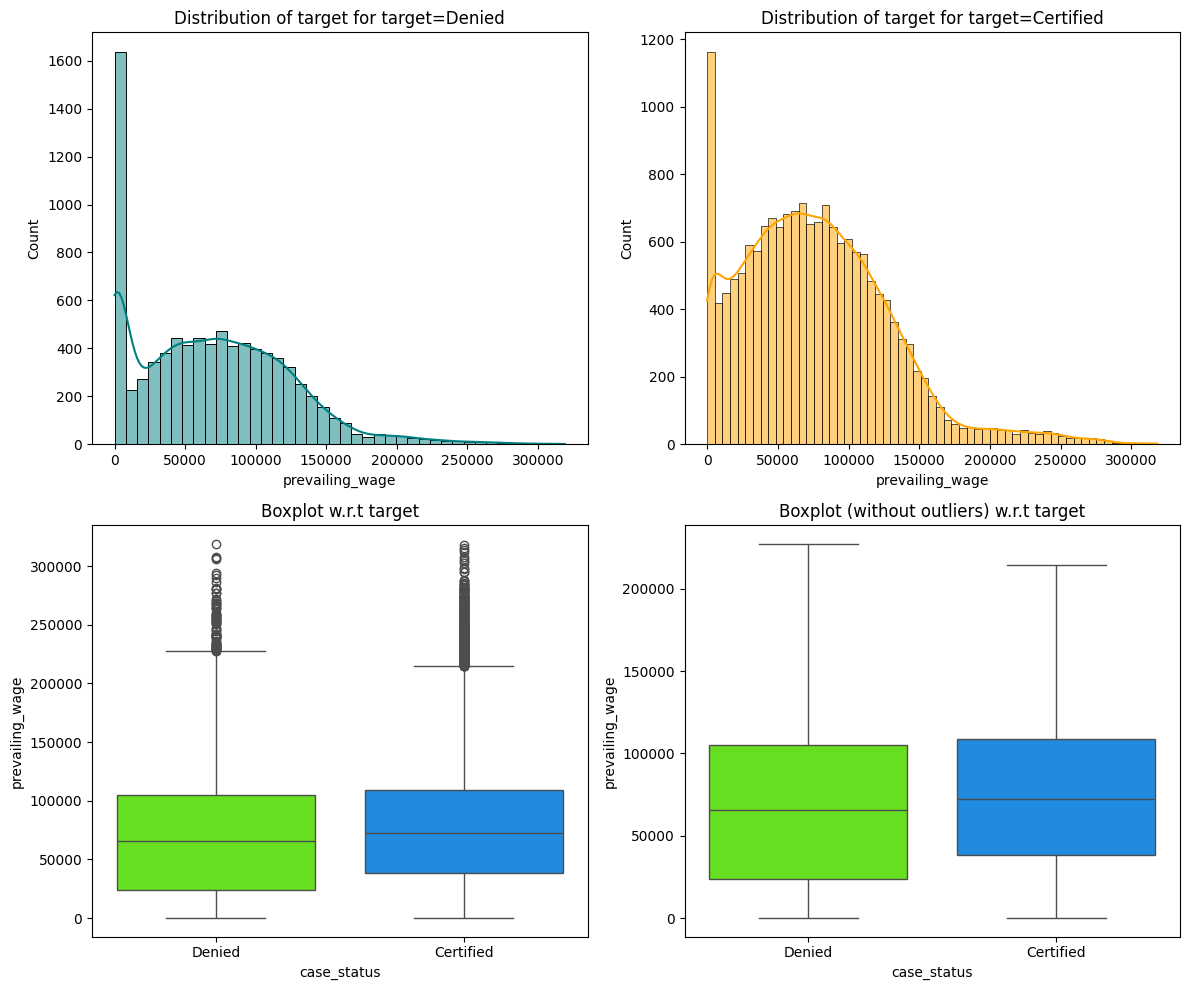

In [ ]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

**Observations**
* The majority of applicants have wages below $100,000.
* Wages do not appear to have a strong influence on case certification, as both distributions are quite similar.
* Outliers (high wage values) significantly affect the overall distribution and considered carefully in analysis.

### Year of Establishment vs Visa Status

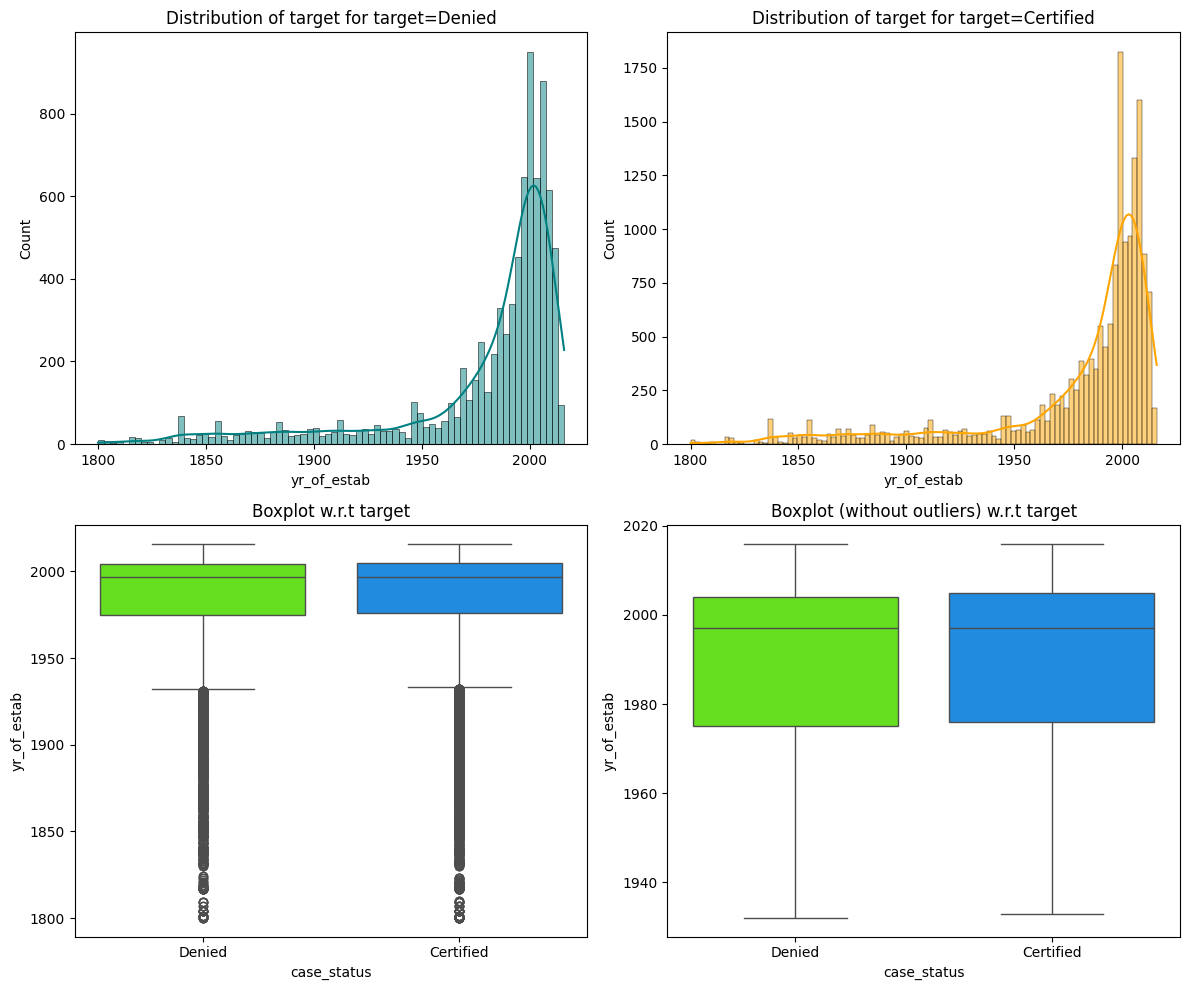

In [ ]:
distribution_plot_wrt_target(data, "yr_of_estab", "case_status")

**Observations**
*	Most applications come from relatively new companies (founded after 1980).
*The establishment year does not seem to have a strong influence on whether an application is denied or certified.
*Very old companies (pre-1900) are rare but exist as outliers.


## Data Preprocessing

### Feature Engineering

In [9]:
data["yr_of_estab"].nunique()

199

* There are 199 unique years in data, we can reduce the levels by grouping them into 3 major categories:
  * mid_1800 - with years betwenn 1800 and 1976
  * mid_1900 - with years betwenn 1976 and 1997
  * early_2000 - with years above 2000

We will bin the data after splitting into train/test/val to avoid data leakage.

In [ ]:
data["yr_of_estab"].describe()

,yr_of_estab
count,25480.000
mean,1979.410
std,42.367
min,1800.000
25%,1976.000
50%,1997.000
75%,2005.000
max,2016.000


In [10]:
# Discretize variable into equal-sized buckets based on quantiles
data["year_of_estab"] = pd.qcut(
    data["yr_of_estab"],
    q=[0, 0.25, 0.5, 1],
    labels=["mid_1800", "mid_1900", "early_2000"],
)

In [11]:
data["year_of_estab"].value_counts()

,count
year_of_estab,
early_2000,12473
mid_1900,6535
mid_1800,6472


###check for negative values in No of Employees in dataset.

In [12]:
#Count How many negative value data for no of employee
data[data['no_of_employees']<0].shape[0]

33

In [13]:
data['no_of_employees'] = data['no_of_employees'].abs()

In [14]:
data[data['no_of_employees']<0].shape[0]

0

###Convert the unit_of_wage into a standardized yearly wage to make comparisons easier

In [15]:
#Convert the unit_of_wage into a standardized yearly wage to make comparisons easier
unit_of_wage_year_scalar = {'Hour': 40*52, 'Week': 52, 'Month': 12, 'Year' :1}
data['prevailing_wage'] = data['prevailing_wage'] * data['unit_of_wage'].map(unit_of_wage_year_scalar)

In [16]:
data1=data.copy()

In [17]:
data1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  object  
 1   education_of_employee  25480 non-null  object  
 2   has_job_experience     25480 non-null  object  
 3   requires_job_training  25480 non-null  object  
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  object  
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  object  
 9   full_time_position     25480 non-null  object  
 10  case_status            25480 non-null  object  
 11  year_of_estab          25480 non-null  category
dtypes: category(1), float64(1), int64(2), object(8)
memory usage: 2.2+ MB


### Values encoded for each categorical column

In [18]:
# we need to pass numerical values for each categorical column for imputation so we will label encode them
education_of_employee = {"High School": 0, "Bachelor's": 1, "Master's": 2, "Doctorate": 3}
data1["education_of_employee"] = data1["education_of_employee"].map(education_of_employee)

continent = {"Asia": 0, "Africa": 1, "Europe": 2, "North America": 3, "South America": 4, "Oceania": 5}
data1["continent"] = data1["continent"].map(continent)

region_of_employment = {
    "Island": 0,
    "Midwest": 1,
    "Northeast": 2,
    "South": 3,
    "West": 4,
}
data1["region_of_employment"] = data1["region_of_employment"].map(region_of_employment)

unit_of_wage = {
    "Hour": 0,
    "Week": 1,
    "Month": 2,
    "Year": 3,
  }
data1["unit_of_wage"] = data1["unit_of_wage"].map(unit_of_wage)

full_time_position = {"N": 0, "Y": 1}
data1["full_time_position"] = data1["full_time_position"].map(full_time_position)

In [19]:
data1.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,year_of_estab
0,0,0,N,N,14513,2007,4,1231782.032,0,1,Denied,early_2000
1,0,2,Y,N,2412,2002,2,83425.650,3,1,Certified,early_2000
2,0,1,N,Y,44444,2008,4,122996.860,3,1,Denied,early_2000
3,0,1,N,N,98,1897,4,83434.030,3,1,Denied,mid_1800
4,1,2,Y,N,1082,2005,3,149907.390,3,1,Certified,early_2000


In [20]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  int64   
 1   education_of_employee  25480 non-null  int64   
 2   has_job_experience     25480 non-null  object  
 3   requires_job_training  25480 non-null  object  
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  int64   
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  int64   
 9   full_time_position     25480 non-null  int64   
 10  case_status            25480 non-null  object  
 11  year_of_estab          25480 non-null  category
dtypes: category(1), float64(1), int64(7), object(3)
memory usage: 2.2+ MB


* Values have been encoded.
* There are no missing value.

### Data Preparation for Modeling

In [21]:
X = data1.drop(["case_status"], axis=1)
y = data1["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

In [22]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 11) (5096, 11) (5096, 11)


In [23]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 15288
Number of rows in validation data = 5096
Number of rows in test data = 5096


In [ ]:
# Checking that no column has missing values in train, validation or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
year_of_estab            0
dtype: int64
------------------------------
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
year_of_estab            0
dtype: int64
------------------------------
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
year_of_estab            0
dtype: int64


* No Missing Value.
* Let's inverse map the encoded values.

### Reverse Mapping for Encoded Variables

In [24]:
## Function to inverse the encoding
def inverse_mapping(x, y):
    inv_dict = {v: k for k, v in x.items()}
    X_train[y] = np.round(X_train[y]).map(inv_dict).astype("category")
    X_val[y] = np.round(X_val[y]).map(inv_dict).astype("category")
    X_test[y] = np.round(X_test[y]).map(inv_dict).astype("category")

In [25]:
inverse_mapping(education_of_employee, "education_of_employee")
inverse_mapping(continent, "continent")
inverse_mapping(region_of_employment, "region_of_employment")
inverse_mapping(unit_of_wage, "unit_of_wage")
inverse_mapping(full_time_position, "full_time_position")


* Checking inverse mapped values/categories.

##Train Dataset

In [26]:
cols = X_train.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_train[i].value_counts())
    print("*" * 30)

continent
Asia             10085
Europe            2285
North America     1944
South America      528
Africa             333
Oceania            113
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     6141
Master's       5792
High School    2045
Doctorate      1310
Name: count, dtype: int64
******************************
has_job_experience
Y    8845
N    6443
Name: count, dtype: int64
******************************
requires_job_training
N    13477
Y     1811
Name: count, dtype: int64
******************************
region_of_employment
Northeast    4312
South        4248
West         3920
Midwest      2576
Island        232
Name: count, dtype: int64
******************************
unit_of_wage
Year     13786
Hour      1286
Week       156
Month       60
Name: count, dtype: int64
******************************
full_time_position
Y    13678
N     1610
Name: count, dtype: int64
******************************
year_of_estab
early_2000    7503
mid_1900  

##Validation Dataset

In [27]:
cols = X_val.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_val[i].value_counts())
    print("*" * 30)

continent
Asia             3395
Europe            713
North America     655
South America     173
Africa            121
Oceania            39
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     2033
Master's       1886
High School     694
Doctorate       483
Name: count, dtype: int64
******************************
has_job_experience
Y    2963
N    2133
Name: count, dtype: int64
******************************
requires_job_training
N    4501
Y     595
Name: count, dtype: int64
******************************
region_of_employment
Northeast    1430
South        1389
West         1352
Midwest       855
Island         70
Name: count, dtype: int64
******************************
unit_of_wage
Year     4576
Hour      452
Week       57
Month      11
Name: count, dtype: int64
******************************
full_time_position
Y    4552
N     544
Name: count, dtype: int64
******************************
year_of_estab
early_2000    2497
mid_1800      1335
mid_1

##Test Dataset

In [28]:
cols = X_test.select_dtypes(include=["object", "category"])
for i in cols.columns:
    print(X_test[i].value_counts())
    print("*" * 30)

continent
Asia             3381
Europe            734
North America     693
South America     151
Africa             97
Oceania            40
Name: count, dtype: int64
******************************
education_of_employee
Bachelor's     2060
Master's       1956
High School     681
Doctorate       399
Name: count, dtype: int64
******************************
has_job_experience
Y    2994
N    2102
Name: count, dtype: int64
******************************
requires_job_training
N    4547
Y     549
Name: count, dtype: int64
******************************
region_of_employment
Northeast    1453
South        1380
West         1314
Midwest       876
Island         73
Name: count, dtype: int64
******************************
unit_of_wage
Year     4600
Hour      419
Week       59
Month      18
Name: count, dtype: int64
******************************
full_time_position
Y    4543
N     553
Name: count, dtype: int64
******************************
year_of_estab
early_2000    2473
mid_1800      1324
mid_1

* Inverse mapping returned original labels.

### Creating Dummy Variables

In [29]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_train = X_train.astype(float)

X_val = pd.get_dummies(X_val, drop_first=True)
X_val = X_val.astype(float)

X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.astype(float)

print(X_train.shape, X_val.shape, X_test.shape)

(15288, 23) (5096, 23) (5096, 23)


* After encoding there are 23 columns.




# Model Building

## Model evaluation criterion

**Model can make wrong predictions as:**
1. A visa application is incorrectly predicted as "Certified" when it is actually "Denied." (FP)
2. A visa application is incorrectly predicted as "Denied" when it is actually "Certified." . (FN)

**Which case is more important?**
* Predicting an employee denied but actually is certified. i.e. This could lead to rejecting a qualified applicant, impacting businesses that need foreign workers.

**How to reduce this loss i.e need to reduce False Negatives?**
* Company would want Recall to be maximized, greater the Recall lesser the chances of false negatives.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [30]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [31]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Initial Model Building

### Model Building - Original Data

In [32]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9896180215475024
Random forest: 1.0
GBM: 0.8766895200783545
Adaboost: 0.8877571008814887
dtree: 1.0

Validation Performance:

Bagging: 0.7834900117508813
Random forest: 0.8313748531139835
GBM: 0.8689776733254995
Adaboost: 0.8816098707403055
dtree: 0.745005875440658


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9881, Validation Score: 0.7544, Difference: 0.2336
Random forest: Training Score: 1.0000, Validation Score: 0.8355, Difference: 0.1645
GBM: Training Score: 0.9576, Validation Score: 0.9515, Difference: 0.0061
Adaboost: Training Score: 0.9781, Validation Score: 0.9771, Difference: 0.0010
dtree: Training Score: 1.0000, Validation Score: 0.6827, Difference: 0.3173


- AdaBoost has the best performance since it has a high validation score (0.9771) and the lowest overfitting (0.0010 difference).
* GBM is a close second with a validation score of 0.9515 and only a 0.0061 difference.
* Random Forest performs decently but has a larger overfitting gap (0.1645).
* Decision Tree and Bagging are overfitting significantly, making them unreliable for real-world predictions.

### Model Building - Oversampled Data

In [33]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 23)
After Oversampling, the shape of train_y: (20420,) 



In [34]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9849167482859941
Random forest: 1.0
GBM: 0.8635651322233104
Adaboost: 0.8539666993143976
dtree: 1.0

Validation Performance:

Bagging: 0.782021151586369
Random forest: 0.8290246768507638
GBM: 0.8557579318448884
Adaboost: 0.8440070505287897
dtree: 0.7388366627497063


In [35]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9849, Validation Score: 0.7820, Difference: 0.2029
Random forest: Training Score: 1.0000, Validation Score: 0.8290, Difference: 0.1710
GBM: Training Score: 0.8636, Validation Score: 0.8558, Difference: 0.0078
Adaboost: Training Score: 0.8540, Validation Score: 0.8440, Difference: 0.0100
dtree: Training Score: 1.0000, Validation Score: 0.7388, Difference: 0.2612


- After Over sampling GBM is the best model because it has the highest validation score (0.8558) and the smallest difference (0.0078).
- Adaboost is a close second, performing slightly worse than GBM but still very reliable.
- Random Forest is decent but overfits more than GBM and Adaboost.
- Bagging and Decision Tree overfit too much, making them unreliable.

### Model Building - Undersampled Data

In [36]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [37]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 23)
After Under Sampling, the shape of train_y: (10156,) 



In [38]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.967703820401733
Random forest: 1.0
GBM: 0.7497046081134305
Adaboost: 0.7142575817250886
dtree: 1.0

Validation Performance:

Bagging: 0.6113396004700352
Random forest: 0.6695064629847238
GBM: 0.7288484136310224
Adaboost: 0.7079905992949471
dtree: 0.6336662749706228


In [39]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9677, Validation Score: 0.6113, Difference: 0.3564
Random forest: Training Score: 1.0000, Validation Score: 0.6695, Difference: 0.3305
GBM: Training Score: 0.7497, Validation Score: 0.7288, Difference: 0.0209
Adaboost: Training Score: 0.7143, Validation Score: 0.7080, Difference: 0.0063
dtree: Training Score: 1.0000, Validation Score: 0.6337, Difference: 0.3663


- after undersampling Adaboost is the best model because it has the smallest generalization gap (0.0063) and a strong validation score (0.7080).
- GBM is a close second, performing slightly better on validation data but with a slightly higher gap (0.0209).
-Random Forest, Bagging, and Decision Tree overfit too much, making them unreliable.

### Tuning Desision

- After building 15 models, it was observed that both the GBM and Adaboost models, trained on an ondersampled dataset, as well as the GBM model trained on an overrsampled dataset, exhibited strong performance on both the training and validation datasets.
- Sometimes models might overfit after undersampling and oversampling, so it's better to tune the models to get a generalized performance.
- We will tune these 3 models using the same data (undersampled or oversampled) as we trained them on before.

## Hyperparameter Tuning

### Tuning AdaBoostClassifier model with Undersampled data

In [40]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 10, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.9312726426438074:
CPU times: user 1.64 s, sys: 375 ms, total: 2.02 s
Wall time: 58.6 s


In [41]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.1,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)
tuned_adb.fit(X_train_un, y_train_un)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=20, random_state=1)

In [42]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train_un, y_train_un)
adb_train

,Accuracy,Recall,Precision,F1
0,0.687,0.655,0.700,0.677


In [43]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.685,0.660,0.833,0.737


### Tuning  Gradient Boosting model with Undersampled Data

In [45]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1, 'n_estimators': 150, 'max_features': 0.5, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7400581823823746:
CPU times: user 5.18 s, sys: 759 ms, total: 5.94 s
Wall time: 4min 52s


In [46]:
tuned_gbm1 = GradientBoostingClassifier(
    random_state=1,
    subsample=0.9,
    n_estimators=150,
    max_features=0.5,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm1.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=0.5,
                           n_estimators=150, random_state=1, subsample=0.9)

In [47]:
# Checking model's performance on training set
gbm1_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train_un, y_train_un
)
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.707,0.747,0.691,0.718


In [48]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.719,0.739,0.823,0.779


### Tuning Gradient Boosting model with Oversampled data

In [50]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.5, 'n_estimators': 125, 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8724779627815866:
CPU times: user 6.59 s, sys: 1.09 s, total: 7.68 s
Wall time: 7min 56s


In [51]:
tuned_gbm2 = GradientBoostingClassifier(
    random_state=1,
    subsample=0.7,
    n_estimators=125,
    max_features=1,
    learning_rate=1,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm2.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=1, max_features=1, n_estimators=125,
                           random_state=1, subsample=0.7)

In [52]:
# Checking model's performance on training set
gbm2_train = model_performance_classification_sklearn(tuned_gbm1, X_train_over, y_train_over)
gbm2_train

,Accuracy,Recall,Precision,F1
0,0.706,0.746,0.691,0.717


In [54]:
# Checking model's performance on validation set
gbm2_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm2_val

,Accuracy,Recall,Precision,F1
0,0.719,0.739,0.823,0.779


## Model Comparison and Final Model Selection

In [55]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm1_train.T,
        gbm2_train.T,
        adb_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Oversampled data,AdaBoost trained with Undersampled data
Accuracy,0.707,0.706,0.687
Recall,0.747,0.746,0.655
Precision,0.691,0.691,0.700
F1,0.718,0.717,0.677


* Gradient Boosting (whether trained with undersampled or oversampled data) appears to be the best-performing model overall, particularly due to its higher Recall and balanced F1-score.
* AdaBoost's slightly higher Precision might be useful

In [56]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [ gbm1_val.T, gbm2_val.T, adb_val.T], axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Oversampled data,AdaBoost trained with Undersampled data
Accuracy,0.719,0.719,0.685
Recall,0.739,0.739,0.660
Precision,0.823,0.823,0.833
F1,0.779,0.779,0.737


- Gradient Boosting remains the preferred model, especially if Recall and overall balanced performance are important.

In [58]:
gbm2_test = model_performance_classification_sklearn(tuned_gbm2, X_test, y_test)
gbm2_test

,Accuracy,Recall,Precision,F1
0,0.719,0.835,0.766,0.799


- The Gradient boosting model trained on oversampled data has given ~83% recall on the test set
- This performance is in line with what we achieved with this model on the train and validation sets
- So, this is a generalized model

### Feature Importance

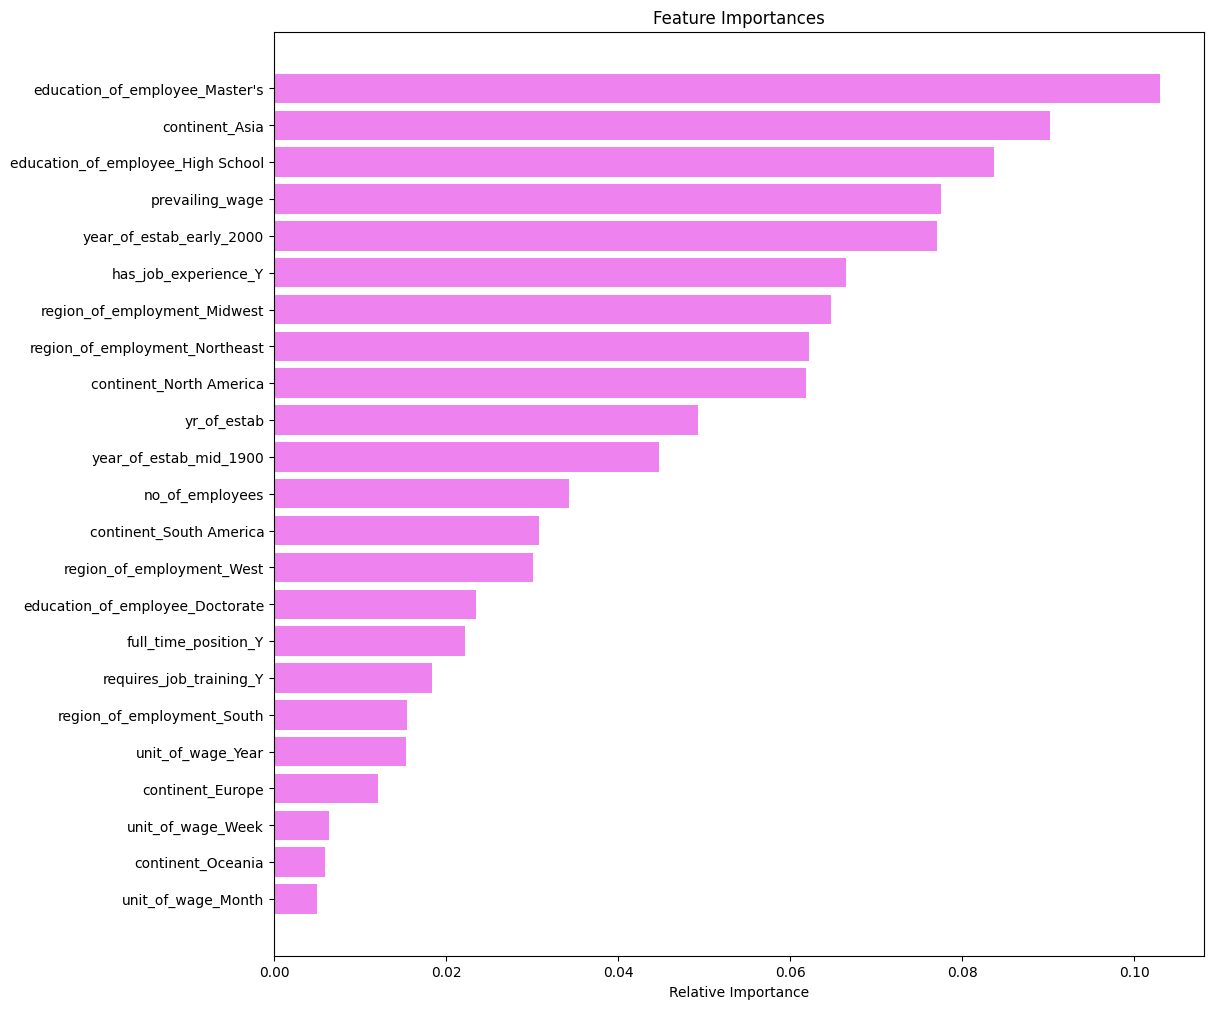

In [61]:
feature_names = X_train.columns
importances = tuned_gbm2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Education level, location (continent and region), wage, and job experience are the most influential factors in the model.
* Company-specific attributes like establishment year and number of employees also play a significant role.
* Employment type and wage payment frequency are less impactful but still contribute to the predictions.

# Business Insights and Recommendations

**Business Insights**
* The most influential factor in visa approval is the education level of the employee, particularly having a Master’s degree.
* Employees from Asia and North America have higher influence on visa approvals, implying that regional demand and past approval trends might be shaping these patterns.
* Prevailing wage is a key determinant, meaning higher salaries may increase the chances of visa approval.
*Job experience plays a significant role, suggesting that experienced applicants have a better chance of certification.
* The year of establishment of the employer’s company influences visa approvals, with companies established in the early 2000s and mid-1900s showing higher impact.

**Recommendations**
* Focus on applicants with higher education levels (Master’s, Doctorate) and significant job experience to increase visa approval rates.
* Encourage employers to offer competitive prevailing wages to improve applicant success.
* Prioritize visa applications for industries that align with high-demand employment regions like the Midwest and Northeast.
* Develop country/continent-specific visa policies based on past approval trends (e.g., Asia showing strong influence).
